# MongoDB



In [19]:
import csv
from pymongo import MongoClient

client = MongoClient("mongodb://127.0.0.1:27017/")
db = client["netflix"]

db["movies"].drop()
db["watch_history"].drop()
db["reviews"].drop()

with open("Netflix//movies.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    movie_data = [row for row in reader]

db["movies"].insert_many(movie_data)
print(f"Loaded {len(movie_data)} movies")

with open("Netflix//watch_history.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    watch_data = [row for _, row in zip(range(105000), reader)]
    
with open("Netflix//reviews.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    review_data = [row for row in reader]
db["reviews"].insert_many(review_data)

db["watch_history"].insert_many(watch_data)
print(f"Loaded {len(watch_data)} watch records")

with open("Netflix//recommendation_logs.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    recommendation_data = [row for row in reader]
db["recommendation"].insert_many(recommendation_data)


list_of_collections = db.list_collection_names()
list_of_collections

Loaded 1040 movies
Loaded 105000 watch records


['reviews', 'recommendation', 'movies', 'watch_history']

# Review



In [20]:
import os
import sys

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

In [21]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, explode, count, avg, row_number, to_date, regexp_replace, lower, length
from pyspark.sql.window import Window

spark = SparkSession.builder.appName("NetflixDataProcessing").getOrCreate()

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [23]:

reviews_df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("Netflix/reviews.csv")

movies_df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("Netflix/movies.csv")

In [24]:
movies_df.drop_duplicates()
reviews_df.drop_duplicates()

DataFrame[review_id: string, user_id: string, movie_id: string, rating: int, review_date: date, device_type: string, is_verified_watch: boolean, helpful_votes: double, total_votes: double, review_text: string, sentiment: string, sentiment_score: double]

## User rating distribution

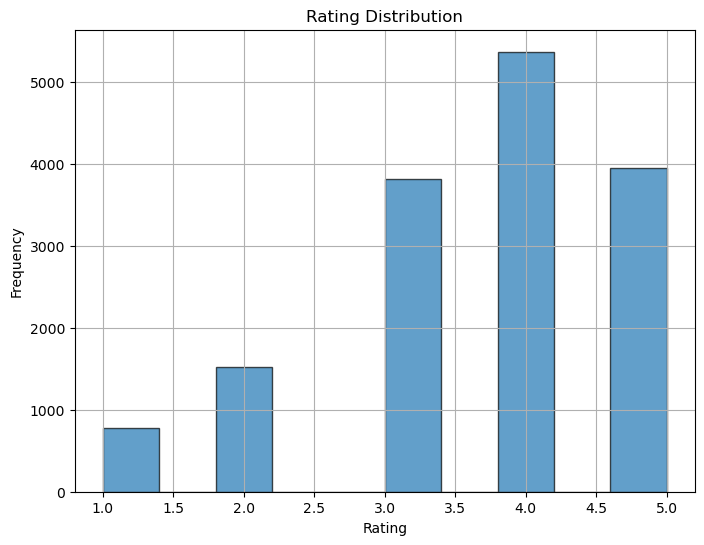

In [25]:


reviews_pd = reviews_df.select("rating").toPandas()

# Plot rating distribution
plt.figure(figsize=(8, 6))
plt.hist(reviews_pd['rating'], bins=10, edgecolor='black', alpha=0.7)
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Rating Distribution')
plt.grid(True)
plt.show()

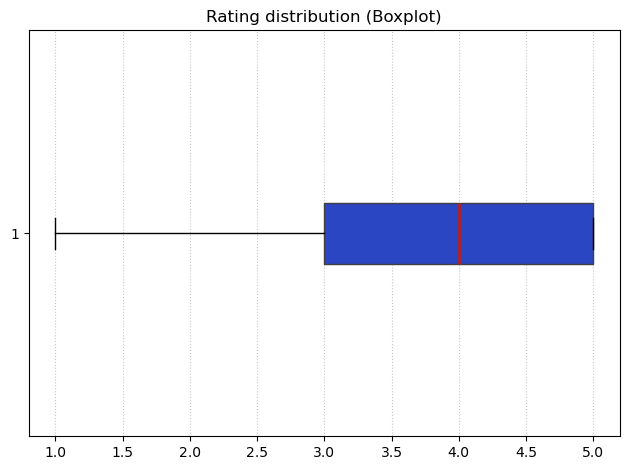

In [26]:

reviews_pd = reviews_df.select("rating").toPandas()

plt.boxplot(reviews_pd['rating'], vert=False, patch_artist=True, 
            boxprops=dict(facecolor="#2a46c3", color='#404040'),
            medianprops=dict(color='firebrick', linewidth=2))


plt.title('Rating distribution (Boxplot)')
plt.grid(True, axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()



# Genre ratings

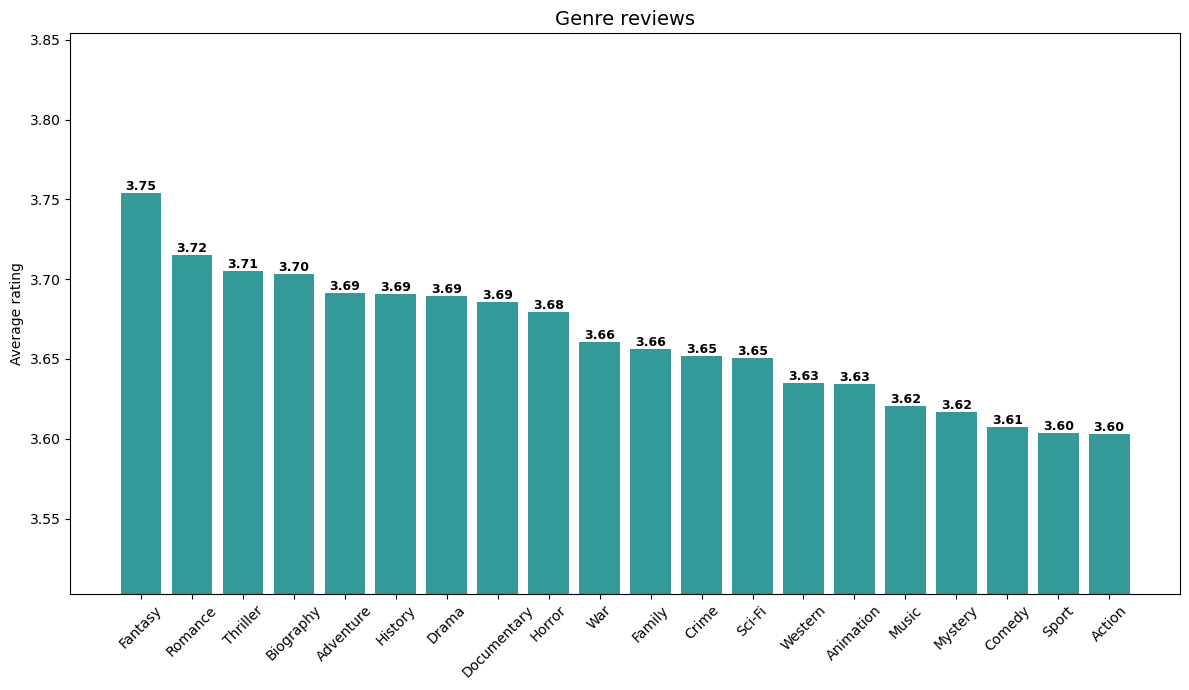

In [27]:

combined_df = reviews_df.join(movies_df, on="movie_id", how="inner").select(
    reviews_df["movie_id"],
    reviews_df["rating"].alias("user_rating"),
    movies_df["genre_primary"]
)

# Lasketaan keskiarvo
genre_stats = combined_df.groupBy("genre_primary").agg(
    {"user_rating": "avg", "movie_id": "count"}
).withColumnRenamed("avg(user_rating)", "avg_rating") \
 .withColumnRenamed("count(movie_id)", "review_count") \
 .orderBy("avg_rating", ascending=False).toPandas()

# Visualisointi
plt.figure(figsize=(12, 7))
bars = plt.bar(genre_stats['genre_primary'], genre_stats['avg_rating'], color='teal', alpha=0.8)

# Y-akselin rajaus
min_rating = genre_stats['avg_rating'].min() - 0.1
max_rating = genre_stats['avg_rating'].max() + 0.1
plt.ylim(min_rating, max_rating)

plt.xticks(rotation=45)
plt.title('Genre reviews', fontsize=14)
plt.ylabel('Average rating')


for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f"{genre_stats ['avg_rating'][i]:.2f}", 
             va='bottom', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('genre_stats.png')

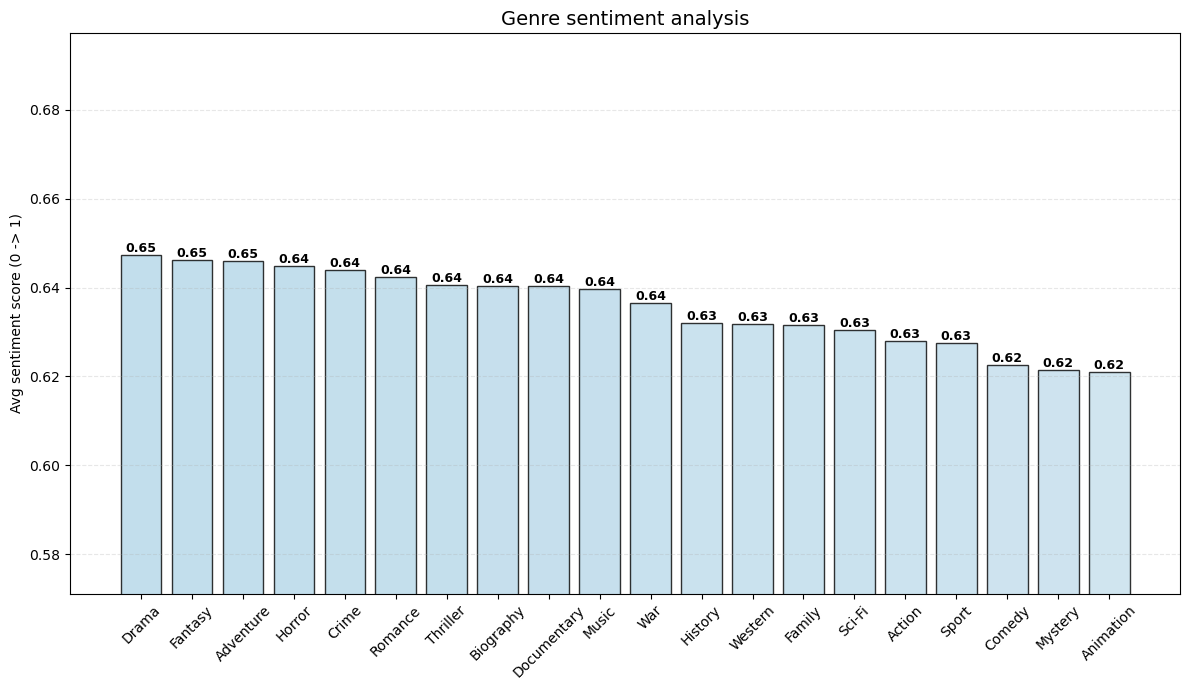

In [28]:
from pyspark.sql.functions import avg, count

# Redefine combined_df to include necessary columns for sentiment analysis
combined_df = reviews_df.join(movies_df, on="movie_id", how="inner").select(
    reviews_df["review_id"],
    reviews_df["sentiment_score"],
    movies_df["genre_primary"]
)

# sentiment score
genre_sentiment = combined_df.groupBy("genre_primary").agg(
    avg("sentiment_score").alias("avg_sentiment"),
    count("review_id").alias("review_count")
).orderBy("avg_sentiment", ascending=False).toPandas()

# 2. Visualisointi
plt.figure(figsize=(12, 7))
colors = plt.cm.RdBu(genre_sentiment['avg_sentiment']) 

bars = plt.bar(genre_sentiment['genre_primary'], genre_sentiment['avg_sentiment'], 
               color=colors, edgecolor='black', alpha=0.8)


plt.ylim(genre_sentiment['avg_sentiment'].min() - 0.05, 
         genre_sentiment['avg_sentiment'].max() + 0.05)

plt.xticks(rotation=45)
plt.title('Genre sentiment analysis', fontsize=14)
plt.ylabel('Avg sentiment score (0 -> 1)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Lisätään tarkat keskiarvot
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f"{genre_sentiment['avg_sentiment'][i]:.2f}", 
             va='bottom', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()